# 1.6 G0 Elastic Reference

This notebook builds the first clean **G0 elastic reference** on the 500-block pilot window.

The workflow is:

$$
H0_{\text{observed}}
\xrightarrow{\text{behavioral priors}}
G0_{\text{Glamsterdam counterfactual}}
\xrightarrow{\text{equilibrium solve}}
\text{G0-local resource shares and elasticities}
$$

In words:

- start from observed H0 quantities and prices;
- reprice the same historical activity under EIP-8037, EIP-7976, and EIP-7981;
- solve a counterfactual G0 equilibrium using H0 behavioral priors;
- recover G0-local implied elasticities for later A/B simulations.

The important distinction is that **G0 is not observed data**. We do not estimate
new elasticities from G0. We transport the H0/Maria/EIP-7623 behavioral priors
into G0, recompute G0 shares, and then recover G0-local implied elasticities.


## Design Choices

This G0 model splits demand into three resources:

$$
\mathcal{R}_{G0}
= \{\text{execution},\ \text{data},\ \text{state}\}
$$

G0 itself still has one shared base-fee path:

$$
u^{\text{base-fee}}_{G0}
= \max\left(g_{\text{regular}},\ g_{\text{state}}\right)
$$

where:

$$
g_{\text{regular}}
= g_{\text{execution}} + g_{\text{data folded into regular}}
$$

For this notebook:

- state is EIP-8037 state gas;
- data is calldata floor repricing plus EIP-7981 access-list data surcharge;
- execution is the remaining G0 regular gas;
- BAL bytes are **not priced in G0** and do **not** consume G0 gas here.

BALs become priced in Mechanism A/B when bandwidth becomes a separate EIP-7999 resource.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip1559 import update_eip1559_base_fee
from demand import (
    Anchor,
    DemandParams,
    demand_at_price_ratios,
    FeeDimension,
    WorldSpec,
    anchor_from_equilibrium,
    implied_anchor_elasticities,
    solve_equilibrium,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

START_BLOCK = 24_120_001
END_BLOCK = 24_120_500
BLOCK_LABEL = f"{START_BLOCK}_{END_BLOCK}"

G0_REPRICING_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_{BLOCK_LABEL}.csv"
FULL_7999_REPLAY_CSV = DATA_DIR / f"full_7999_replay_{BLOCK_LABEL}.csv"
EIP7623_ELASTICITY_CSV = DATA_DIR / "eip7623_event_implied_elasticity_sweep_2025-03-07_2025-07-08.csv"

OUT_DECOMP_CSV = DATA_DIR / f"g0_reference_decomposition_{BLOCK_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"g0_elastic_reference_results_{BLOCK_LABEL}.csv"
OUT_SWEEP_CSV = DATA_DIR / f"g0_eta_data_sweep_{BLOCK_LABEL}.csv"
OUT_ELASTIC_REPLAY_CSV = DATA_DIR / f"g0_elastic_replay_diagnostic_{BLOCK_LABEL}.csv"
OUT_DYNAMIC_REPLAY_CSV = DATA_DIR / f"g0_dynamic_elastic_replay_check_{BLOCK_LABEL}.csv"
OUT_BASEFEE_MODEL_CSV = DATA_DIR / f"g0_equilibrium_base_fee_model_{BLOCK_LABEL}.csv"

SHARE_MODE = "maria_own_price"

## Load The 500-Block Inputs

The 500-block pilot window already has transaction-level G0 regular-gas repricing from notebook `0.6` and passive G0 replay from notebook `0.7`.

We also merge the current EIP-7623 calldata de-accounting from the full-7999 replay file, because H0 data should include the current calldata floor uplift. That avoids hiding current data gas inside execution.

In [2]:
g0_raw = pd.read_csv(G0_REPRICING_CSV)
current_data = pd.read_csv(FULL_7999_REPLAY_CSV)[[
    "block_number",
    "standard_calldata_gas_current",
    "current_7623_floor_uplift_observed",
    "current_calldata_deaccounted_gas",
    "bal_rlp_bytes",
]]

blocks = g0_raw.merge(current_data, on="block_number", how="inner", validate="one_to_one")

assert len(blocks) == 500
assert (blocks["standard_calldata_gas"] == blocks["standard_calldata_gas_current"]).all()

blocks[["block_number", "timestamp", "current_gas_used_from_txs", "regular_gas_glamsterdam", "state_gas_8037"]].head()

,block_number,timestamp,current_gas_used_from_txs,regular_gas_glamsterdam,state_gas_8037
0,24120001,2025-12-29 18:10:35,59964904,54038829,42310620
1,24120002,2025-12-29 18:10:47,13753679,11765253,13693500
2,24120003,2025-12-29 18:10:59,41015898,34135767,43098570
3,24120004,2025-12-29 18:11:11,23756933,19321970,31432320
4,24120005,2025-12-29 18:11:23,16941785,15323901,13558860


## Decompose H0 And Passive G0

H0 is the observed current world. The three H0 physical quantities are measured in current-rule gas units:

$$
\text{state}_{H0}
= \text{historical current-rule state creation gas}
$$

$$
\text{data}_{H0}
= \text{standard calldata gas} + \text{current EIP-7623 floor uplift}
$$

$$
\text{execution}_{H0}
= \text{current gas used} - \text{state}_{H0} - \text{data}_{H0}
$$

Passive G0 maps the same historical activity into Glamsterdam metered gas:

$$
\text{state}_{G0}
= \text{EIP-8037 state gas}
$$

$$
\text{data}_{G0}
= \text{standard calldata gas}
+ \text{EIP-7976 floor uplift}
+ \text{EIP-7981 access-list data cost}
$$

$$
\text{execution}_{G0}
= \text{regular gas}_{G0} - \text{data}_{G0}
$$

No BAL term appears in these G0 gas equations.

In [3]:
# H0 observed components.
blocks["h0_state_gas"] = blocks["historical_state_creation_gas_total"]
blocks["h0_data_gas"] = blocks["current_calldata_deaccounted_gas"]
blocks["h0_execution_gas"] = (
    blocks["current_gas_used_from_txs"]
    - blocks["h0_state_gas"]
    - blocks["h0_data_gas"]
)

# Passive G0 metered components. BAL is deliberately excluded.
blocks["g0_state_gas"] = blocks["state_gas_8037"]
blocks["g0_data_gas"] = (
    blocks["standard_calldata_gas"]
    + blocks["glamsterdam_7976_floor_uplift"]
    + blocks["access_list_data_cost_7981"]
)
blocks["g0_execution_gas"] = blocks["regular_gas_glamsterdam"] - blocks["g0_data_gas"]
blocks["g0_regular_gas"] = blocks["g0_execution_gas"] + blocks["g0_data_gas"]
blocks["g0_max_regular_state_gas"] = blocks[["g0_regular_gas", "g0_state_gas"]].max(axis=1)
blocks["g0_bottleneck"] = np.where(
    blocks["g0_regular_gas"] >= blocks["g0_state_gas"],
    "regular",
    "state",
)

for col in ["h0_execution_gas", "h0_data_gas", "h0_state_gas", "g0_execution_gas", "g0_data_gas", "g0_state_gas"]:
    if (blocks[col] < 0).any():
        raise ValueError(f"negative values in {col}")

blocks.to_csv(OUT_DECOMP_CSV, index=False)

summary = pd.DataFrame([
    {
        "world": "H0_observed",
        "execution_gas_M": blocks["h0_execution_gas"].mean() / 1e6,
        "data_gas_M": blocks["h0_data_gas"].mean() / 1e6,
        "state_gas_M": blocks["h0_state_gas"].mean() / 1e6,
        "regular_gas_M": (blocks["h0_execution_gas"] + blocks["h0_data_gas"]).mean() / 1e6,
        "max_regular_state_gas_M": blocks["current_gas_used_from_txs"].mean() / 1e6,
    },
    {
        "world": "G0_passive_repriced",
        "execution_gas_M": blocks["g0_execution_gas"].mean() / 1e6,
        "data_gas_M": blocks["g0_data_gas"].mean() / 1e6,
        "state_gas_M": blocks["g0_state_gas"].mean() / 1e6,
        "regular_gas_M": blocks["g0_regular_gas"].mean() / 1e6,
        "max_regular_state_gas_M": blocks["g0_max_regular_state_gas"].mean() / 1e6,
    },
])
summary

,world,execution_gas_M,data_gas_M,state_gas_M,regular_gas_M,max_regular_state_gas_M
0,H0_observed,24.462873,1.072056,4.935713,25.534929,30.470642
1,G0_passive_repriced,25.042216,2.042926,28.665593,27.085142,33.316308


In [4]:
h0_totals = {
    "execution": float(blocks["h0_execution_gas"].sum()),
    "data": float(blocks["h0_data_gas"].sum()),
    "state": float(blocks["h0_state_gas"].sum()),
}

g0_totals = {
    "execution": float(blocks["g0_execution_gas"].sum()),
    "data": float(blocks["g0_data_gas"].sum()),
    "state": float(blocks["g0_state_gas"].sum()),
}

multipliers = {name: g0_totals[name] / h0_totals[name] for name in h0_totals}
shares_h0 = {name: h0_totals[name] / sum(h0_totals.values()) for name in h0_totals}
shares_g0_passive_physical = {
    name: h0_totals[name] / sum(h0_totals.values()) for name in h0_totals
}
shares_g0_passive_metered = {name: g0_totals[name] / sum(g0_totals.values()) for name in g0_totals}

multiplier_table = pd.DataFrame([
    {
        "resource": name,
        "h0_mean_gas_M": h0_totals[name] / len(blocks) / 1e6,
        "g0_passive_metered_mean_gas_M": g0_totals[name] / len(blocks) / 1e6,
        "g0_metering_multiplier": multipliers[name],
        "h0_physical_share": shares_h0[name],
        "g0_passive_metered_share": shares_g0_passive_metered[name],
    }
    for name in ["execution", "data", "state"]
])
multiplier_table

,resource,h0_mean_gas_M,g0_passive_metered_mean_gas_M,g0_metering_multiplier,h0_physical_share,g0_passive_metered_share
0,execution,24.462873,25.042216,1.023683,0.802834,0.449182
1,data,1.072056,2.042926,1.905615,0.035183,0.036644
2,state,4.935713,28.665593,5.807792,0.161983,0.514174


## H0 Behavioral Priors

We use:

$$
\epsilon_{\text{agg}} = 0.175
$$

from Maria's gas-limit-increase event estimate, and:

$$
\eta_{\text{state}} = 0.43
$$

from Maria's long-run state-share estimate.

For the data-vs-execution split, the central object is now the **recovered calldata own-price elasticity** from the state-cleaned EIP-7623 event study:

$$
\epsilon_{\text{data}}^{\text{prior}} \approx 0.487
$$

We use this as an external data-elasticity prior for the 500-block pilot instead of re-deriving $\epsilon_{\text{data}}$ from the pilot sample composition. The nested demand model is parameterized by $\eta_{\text{data}}$, so below we convert the fixed $\epsilon_{\text{data}}^{\text{prior}}$ into the model-implied $\eta_{\text{data}}$ at the H0 pilot anchor:

$$
\eta_{\text{data}}^{\text{model}}
=
\frac{
  \epsilon_{\text{data}}^{\text{prior}}
  - \epsilon_{\text{rest}}^{H0}
}{
  1 - \alpha_{\text{data}|\text{rest}}^{H0}
}
$$

This keeps the EIP-7623 data-elasticity prior fixed while still letting the model use the data/rest shares required by the nested demand equations.


In [5]:
EPS_AGG = 0.175
ETA_STATE_CENTRAL = 0.43

eta_sweep = pd.read_csv(EIP7623_ELASTICITY_CSV)
eip7623_prior_row = eta_sweep.loc[
    eta_sweep["interpretation"].eq("state-cleaned long-window effective eta")
].iloc[0]

EPSILON_DATA_CENTRAL = float(eip7623_prior_row["epsilon_data"])
ETA_DATA_EVENT_STUDY = float(eip7623_prior_row["eta_data"])

# Keep the 1.4 sweep values as data-elasticity priors. We will convert each
# one into the model's eta_data parameter at the H0 pilot anchor below.
epsilon_data_prior_table = eta_sweep[[
    "eta_data",
    "epsilon_data",
    "epsilon_execution",
    "interpretation",
]].rename(columns={
    "eta_data": "eta_data_event_study",
    "epsilon_data": "epsilon_data_prior",
    "epsilon_execution": "epsilon_execution_1_4_basis",
})

print("EPSILON_DATA_CENTRAL", EPSILON_DATA_CENTRAL)
print("ETA_DATA_EVENT_STUDY", ETA_DATA_EVENT_STUDY)
epsilon_data_prior_table


EPSILON_DATA_CENTRAL 0.4868758860939447
ETA_DATA_EVENT_STUDY 0.4294175530575123


,eta_data_event_study,epsilon_data_prior,epsilon_execution_1_4_basis,interpretation
0,0.000000,0.080000,0.080000,fixed data/execution split
1,0.100000,0.174751,0.074751,sensitivity
2,0.300000,0.364252,0.064252,sensitivity
3,0.430000,0.487428,0.057428,state-cleaned EIP-7623 central prior
4,0.600000,0.648504,0.048504,sensitivity
5,1.000000,1.027506,0.027506,aggressive short-run sensitivity
6,0.326236,0.389110,0.062875,main long-window effective eta
7,0.429418,0.486876,0.057458,state-cleaned long-window effective eta


## Solve The G0 Equilibrium

The central G0 scenario is a 100M `max(regular, state)` gas limit, which corresponds to a 50M EIP-1559 target.

We also include a 200M-limit sensitivity with a 100M target.

The world has one shared fee dimension:

$$
u_{G0}
= \max\left(
  m_{\text{execution}}q_{\text{execution}}
  + m_{\text{data}}q_{\text{data}},
  m_{\text{state}}q_{\text{state}}
\right)
$$

where:

- $q_r$ is physical H0-style demand for resource $r$ after the demand response;
- $m_r$ is the G0/H0 metering multiplier for resource $r$;
- $u_{G0}$ is the gas-use input that must equal the target at equilibrium, unless the model hits a floor.


In [6]:
base_fee_ref = float(blocks["base_fee_per_gas"].median())
h0_quantities = {
    "execution": float(blocks["h0_execution_gas"].mean()),
    "data": float(blocks["h0_data_gas"].mean()),
    "state": float(blocks["h0_state_gas"].mean()),
}

anchor_h0 = Anchor(
    quantities=h0_quantities,
    effective_prices={name: base_fee_ref for name in h0_quantities},
)

def eta_data_from_fixed_epsilon(
    *,
    epsilon_data_prior: float,
    epsilon_rest: float,
    alpha_data_given_rest: float,
) -> float:
    if not 0 <= alpha_data_given_rest < 1:
        raise ValueError("alpha_data_given_rest must be in [0, 1)")
    return max(0.0, (epsilon_data_prior - epsilon_rest) / (1.0 - alpha_data_given_rest))


def recover_from_fixed_epsilon_data(
    *,
    epsilon_rest: float,
    alpha_data_given_rest: float,
    epsilon_data_prior: float,
) -> dict:
    """Recover execution elasticity implied by a fixed data elasticity prior."""

    epsilon_execution = (
        epsilon_rest - alpha_data_given_rest * epsilon_data_prior
    ) / (1.0 - alpha_data_given_rest)
    eta_data_local = epsilon_data_prior - epsilon_execution
    return {
        "epsilon_data_prior": epsilon_data_prior,
        "epsilon_execution": epsilon_execution,
        "eta_data_local_from_fixed_epsilon": eta_data_local,
        "valid_nonnegative_execution": epsilon_execution >= 0,
    }


def recover_from_model_eta(
    epsilon_rest: float,
    alpha_data_given_rest: float,
    eta_data: float,
) -> dict:
    """Diagnostic: the old local recovery implied by the model eta itself."""

    epsilon_data = epsilon_rest + eta_data * (1.0 - alpha_data_given_rest)
    epsilon_execution = epsilon_rest - eta_data * alpha_data_given_rest
    return {
        "epsilon_data_local_from_model_eta": epsilon_data,
        "epsilon_execution_local_from_model_eta": epsilon_execution,
    }


h0_implied_for_data_prior = implied_anchor_elasticities(
    anchor_h0,
    DemandParams(
        eps_agg=EPS_AGG,
        eta_state=ETA_STATE_CENTRAL,
        eta_data=0.0,
        share_mode=SHARE_MODE,
    ),
)
EPSILON_REST_H0 = h0_implied_for_data_prior["rest"]
ALPHA_DATA_GIVEN_REST_H0 = anchor_h0.data_share_of_rest
ETA_DATA_CENTRAL = eta_data_from_fixed_epsilon(
    epsilon_data_prior=EPSILON_DATA_CENTRAL,
    epsilon_rest=EPSILON_REST_H0,
    alpha_data_given_rest=ALPHA_DATA_GIVEN_REST_H0,
)

# Use the 1.4 epsilon_data sweep as the prior grid, but remove the near-duplicate
# old central row so the table has one central value.
epsilon_prior_rows = epsilon_data_prior_table[
    ~epsilon_data_prior_table["interpretation"].eq("state-cleaned EIP-7623 central prior")
].copy()
epsilon_prior_rows["eta_data"] = epsilon_prior_rows["epsilon_data_prior"].map(
    lambda value: eta_data_from_fixed_epsilon(
        epsilon_data_prior=float(value),
        epsilon_rest=EPSILON_REST_H0,
        alpha_data_given_rest=ALPHA_DATA_GIVEN_REST_H0,
    )
)
epsilon_prior_rows["is_central"] = epsilon_prior_rows["interpretation"].eq(
    "state-cleaned long-window effective eta"
)
ETA_DATA_VALUES = epsilon_prior_rows["eta_data"].tolist()

prior_anchor_summary = pd.DataFrame([
    {
        "epsilon_data_prior": EPSILON_DATA_CENTRAL,
        "eta_data_event_study_1_4_basis": ETA_DATA_EVENT_STUDY,
        "epsilon_rest_H0_pilot": EPSILON_REST_H0,
        "alpha_data_given_rest_H0_pilot": ALPHA_DATA_GIVEN_REST_H0,
        "eta_data_model_H0_pilot": ETA_DATA_CENTRAL,
    }
])
display(prior_anchor_summary)

rows = []
for gas_limit in [100_000_000, 200_000_000]:
    target = gas_limit / 2
    world = WorldSpec(
        name=f"G0_glamsterdam_limit_{gas_limit}",
        multipliers=multipliers,
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=target,
            ),
        ),
    )
    for _, prior_row in epsilon_prior_rows.iterrows():
        eta_data = float(prior_row["eta_data"])
        epsilon_data_prior = float(prior_row["epsilon_data_prior"])
        params = DemandParams(
            eps_agg=EPS_AGG,
            eta_state=ETA_STATE_CENTRAL,
            eta_data=eta_data,
            share_mode=SHARE_MODE,
        )
        eq = solve_equilibrium(anchor_h0, params, world)
        anchor_g0 = anchor_from_equilibrium(anchor_h0, world, eq)
        implied = implied_anchor_elasticities(anchor_g0, params)
        alpha_data_given_rest_g0 = anchor_g0.data_share_of_rest
        fixed_prior_recovery = recover_from_fixed_epsilon_data(
            epsilon_rest=implied["rest"],
            alpha_data_given_rest=alpha_data_given_rest_g0,
            epsilon_data_prior=epsilon_data_prior,
        )
        model_eta_recovery = recover_from_model_eta(
            epsilon_rest=implied["rest"],
            alpha_data_given_rest=alpha_data_given_rest_g0,
            eta_data=eta_data,
        )
        regular_metered = (
            eq.quantities["execution"] * multipliers["execution"]
            + eq.quantities["data"] * multipliers["data"]
        )
        state_metered = eq.quantities["state"] * multipliers["state"]
        rows.append({
            "gas_limit": gas_limit,
            "gas_target": target,
            "share_mode": SHARE_MODE,
            "epsilon_data_prior": epsilon_data_prior,
            "eta_data_event_study_1_4_basis": float(prior_row["eta_data_event_study"]),
            "eta_data": eta_data,
            "eta_data_model_H0_pilot": eta_data,
            "is_central": bool(prior_row["is_central"]),
            "prior_interpretation": prior_row["interpretation"],
            "converged": eq.converged,
            "floor_binding": eq.floor_binding["regular_state"],
            "binding_group": "state" if eq.binding_group["regular_state"] == 1 else "regular",
            "base_fee_gwei": eq.prices_wei["regular_state"] / 1e9,
            "base_fee_ratio_to_h0_median": eq.prices_wei["regular_state"] / base_fee_ref,
            "price_index_ratio": eq.price_index_ratio,
            "demand_expansion_x": eq.demand_expansion,
            "execution_physical_gas_M": eq.quantities["execution"] / 1e6,
            "data_physical_gas_M": eq.quantities["data"] / 1e6,
            "state_physical_gas_M": eq.quantities["state"] / 1e6,
            "execution_metered_gas_M": eq.quantities["execution"] * multipliers["execution"] / 1e6,
            "data_metered_gas_M": eq.quantities["data"] * multipliers["data"] / 1e6,
            "state_metered_gas_M": state_metered / 1e6,
            "regular_metered_gas_M": regular_metered / 1e6,
            "g0_basefee_input_gas_M": max(regular_metered, state_metered) / 1e6,
            "alpha_state_G0_physical": anchor_g0.alpha_state,
            "alpha_data_given_rest_G0_physical": alpha_data_given_rest_g0,
            "epsilon_state_G0": implied["state"],
            "epsilon_rest_G0": implied["rest"],
            **fixed_prior_recovery,
            **model_eta_recovery,
        })

results = pd.DataFrame(rows)
results.to_csv(OUT_RESULTS_CSV, index=False)

central = results[
    (results["gas_limit"] == 100_000_000)
    & results["is_central"]
].copy()
central


,epsilon_data_prior,eta_data_event_study_1_4_basis,epsilon_rest_H0_pilot,alpha_data_given_rest_H0_pilot,eta_data_model_H0_pilot
0,0.486876,0.429418,0.105347,0.041984,0.398248


,gas_limit,gas_target,share_mode,epsilon_data_prior,eta_data_event_study_1_4_basis,eta_data,eta_data_model_H0_pilot,is_central,prior_interpretation,converged,...,g0_basefee_input_gas_M,alpha_state_G0_physical,alpha_data_given_rest_G0_physical,epsilon_state_G0,epsilon_rest_G0,epsilon_execution,eta_data_local_from_fixed_epsilon,valid_nonnegative_execution,epsilon_data_local_from_model_eta,epsilon_execution_local_from_model_eta
6,100000000,"50,000,000.000000",maria_own_price,0.486876,0.429418,0.398248,0.398248,True,state-cleaned long-window effective eta,True,...,50.000000,0.205186,0.033084,0.516770,0.086770,0.073080,0.413796,True,0.471843,0.073594


## Central 100M-Limit Interpretation

The table below is the main 100M-limit G0 reference.

We use Maria's original own-price-style interpretation as the central model: state share responds to the resource's effective price after repricing. This is the closest match to the G0 mechanism because EIP-8037 changes state's effective gas cost while G0 still has one shared base-fee path over `max(regular, state)`.


In [7]:
central_display = central[[
    "share_mode",
    "binding_group",
    "base_fee_gwei",
    "base_fee_ratio_to_h0_median",
    "demand_expansion_x",
    "regular_metered_gas_M",
    "state_metered_gas_M",
    "g0_basefee_input_gas_M",
    "alpha_state_G0_physical",
    "alpha_data_given_rest_G0_physical",
    "epsilon_state_G0",
    "epsilon_rest_G0",
    "epsilon_data_prior",
    "epsilon_execution",
    "eta_data_model_H0_pilot",
]]
central_display

,share_mode,binding_group,base_fee_gwei,base_fee_ratio_to_h0_median,demand_expansion_x,regular_metered_gas_M,state_metered_gas_M,g0_basefee_input_gas_M,alpha_state_G0_physical,alpha_data_given_rest_G0_physical,epsilon_state_G0,epsilon_rest_G0,epsilon_data_prior,epsilon_execution,eta_data_model_H0_pilot
6,maria_own_price,state,0.006683,0.087850,1.376989,35.111448,50.000000,50.000000,0.205186,0.033084,0.516770,0.086770,0.486876,0.073080,0.398248


## Equilibrium Base-Fee Model

This plot mirrors Maria's gas-limit/base-fee visualization, but for the G0 counterfactual. The x-axis changes the shared `max(regular, state)` gas limit relative to the H0 60M-ish limit. The y-axis reports the solved G0 equilibrium base fee relative to the H0 median base fee.

There are two curves because they answer different questions.

The dashed reference line is the aggregate-only constant-elasticity benchmark:

$$
\frac{p(L)}{p_{H0}}
=
\left(\frac{L}{L_{H0}}\right)^{-1/\epsilon_{\text{agg}}}
$$

This is a one-resource benchmark. It asks: if the only change were a larger gas limit, and all resources were homogeneous, how much would the equilibrium base fee fall? It ignores state repricing, data repricing, and the `max(regular, state)` bottleneck.

The solid line is the full G0 solved equilibrium. G0 is not just “H0 with a larger gas limit”; it changes the metering system:

- state is repriced by EIP-8037;
- calldata-heavy transactions are affected by EIP-7976;
- access-list data is affected by EIP-7981;
- the shared base-fee input is the bottleneck between regular gas and state gas.

For a candidate G0 gas limit $L$, the target is:

$$
T_{G0} = \frac{L}{2}
$$

The G0 solver searches for the shared base fee $p$ such that demand lands on the target:

$$
u_{G0}(p) = T_{G0}
$$

where:

$$
u_{G0}(p)
=
\max\left(
  g_{\text{regular}}(p),
  g_{\text{state}}(p)
\right)
$$

and:

$$
g_{\text{regular}}(p)
=
  m_{\text{execution}}q_{\text{execution}}(p)
  + m_{\text{data}}q_{\text{data}}(p)
$$

$$
g_{\text{state}}(p)
=
  m_{\text{state}}q_{\text{state}}(p)
$$

Here $q_r(p)$ is the physical demand for resource $r$ after the demand response, and $m_r$ is the G0/H0 metering multiplier for that resource. The quantities come from the nested demand model: aggregate demand responds to the spend-weighted price index, state share responds using Maria's state-vs-rest elasticity, and data/execution share responds using $\eta_{\text{data}}$.

So the new equilibrium model (solid line) says: “after Glamsterdam reprices state and data and meters state separately, and after demand composition responds, what shared base fee clears the `max(regular, state)` target?”

That is why the G0 line can start below the aggregate benchmark even at the H0 gas limit. The G0 curve includes the counterfactual repricing itself, not only a pure gas-limit expansion. The markers show the 100M and 200M scenarios used elsewhere in the notebook.


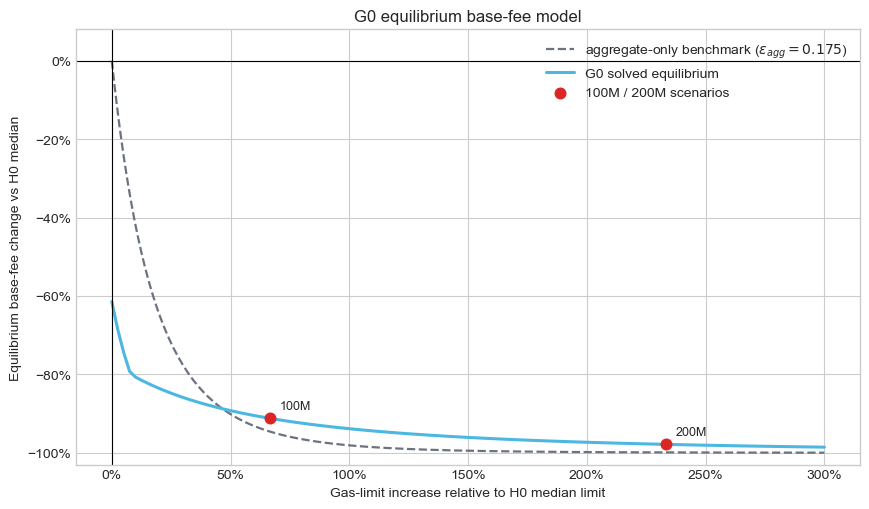

,gas_limit,gas_limit_increase_pct,base_fee_gwei,base_fee_ratio_to_h0_median,demand_expansion_x,g0_basefee_input_gas_M,binding_group
0,"60,000,000.000000",0.000000,0.029341,0.385679,1.062909,30.000000,regular
27,"100,000,000.000000",0.666667,0.006683,0.087850,1.376989,50.000000,state
95,"200,000,000.000000",2.333333,0.001639,0.021540,1.761030,100.000000,state


In [8]:
from matplotlib.ticker import PercentFormatter

h0_reference_gas_limit = float(blocks["gas_limit"].median())
central_params = DemandParams(
    eps_agg=EPS_AGG,
    eta_state=ETA_STATE_CENTRAL,
    eta_data=ETA_DATA_CENTRAL,
    share_mode=SHARE_MODE,
)

gas_limit_grid = np.unique(np.concatenate([
    np.linspace(h0_reference_gas_limit, 240_000_000, 121),
    np.array([100_000_000, 200_000_000], dtype=float),
]))
curve_rows = []
for gas_limit in gas_limit_grid:
    target = gas_limit / 2
    world = WorldSpec(
        name=f"G0_glamsterdam_limit_{int(gas_limit)}",
        multipliers=multipliers,
        dimensions=(
            FeeDimension(
                name="regular_state",
                groups=(("execution", "data"), ("state",)),
                target_gas=target,
            ),
        ),
    )
    eq = solve_equilibrium(anchor_h0, central_params, world)
    regular_metered = (
        eq.quantities["execution"] * multipliers["execution"]
        + eq.quantities["data"] * multipliers["data"]
    )
    state_metered = eq.quantities["state"] * multipliers["state"]
    curve_rows.append({
        "gas_limit": gas_limit,
        "gas_target": target,
        "gas_limit_increase_pct": gas_limit / h0_reference_gas_limit - 1,
        "base_fee_gwei": eq.prices_wei["regular_state"] / 1e9,
        "base_fee_ratio_to_h0_median": eq.prices_wei["regular_state"] / base_fee_ref,
        "base_fee_change_pct": eq.prices_wei["regular_state"] / base_fee_ref - 1,
        "price_index_ratio": eq.price_index_ratio,
        "demand_expansion_x": eq.demand_expansion,
        "regular_metered_gas_M": regular_metered / 1e6,
        "state_metered_gas_M": state_metered / 1e6,
        "g0_basefee_input_gas_M": max(regular_metered, state_metered) / 1e6,
        "binding_group": "state" if eq.binding_group["regular_state"] == 1 else "regular",
    })

g0_base_fee_curve = pd.DataFrame(curve_rows)
g0_base_fee_curve.to_csv(OUT_BASEFEE_MODEL_CSV, index=False)

aggregate_x = np.linspace(0, g0_base_fee_curve["gas_limit_increase_pct"].max(), 300)
aggregate_ratio = (1.0 + aggregate_x) ** (-1.0 / EPS_AGG)
scenario_points = results[
    results["gas_limit"].isin([100_000_000, 200_000_000])
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].copy()
scenario_points["gas_limit_increase_pct"] = scenario_points["gas_limit"] / h0_reference_gas_limit - 1
scenario_points["base_fee_change_pct"] = scenario_points["base_fee_ratio_to_h0_median"] - 1

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.plot(
    aggregate_x,
    aggregate_ratio - 1,
    linestyle="--",
    color="#6B7280",
    linewidth=1.6,
    label=rf"aggregate-only benchmark ($\epsilon_{{agg}}={EPS_AGG}$)",
)
ax.plot(
    g0_base_fee_curve["gas_limit_increase_pct"],
    g0_base_fee_curve["base_fee_change_pct"],
    color="#4CB7E1",
    linewidth=2.2,
    label="G0 solved equilibrium",
)
ax.scatter(
    scenario_points["gas_limit_increase_pct"],
    scenario_points["base_fee_change_pct"],
    color="#DC2626",
    s=58,
    zorder=3,
    label="100M / 200M scenarios",
)
for _, row in scenario_points.iterrows():
    ax.annotate(
        f"{int(row['gas_limit'] / 1e6)}M",
        (row["gas_limit_increase_pct"], row["base_fee_change_pct"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_xlabel("Gas-limit increase relative to H0 median limit")
ax.set_ylabel("Equilibrium base-fee change vs H0 median")
ax.set_title("G0 equilibrium base-fee model")
ax.set_ylim(-1.03, 0.08)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_equilibrium_base_fee_model_{BLOCK_LABEL}.png", dpi=160)
plt.show()

g0_base_fee_curve.loc[
    g0_base_fee_curve["gas_limit"].round().isin([round(h0_reference_gas_limit), 100_000_000, 200_000_000]),
    [
        "gas_limit",
        "gas_limit_increase_pct",
        "base_fee_gwei",
        "base_fee_ratio_to_h0_median",
        "demand_expansion_x",
        "g0_basefee_input_gas_M",
        "binding_group",
    ],
]


## Dynamic Elastic Replay Check

The previous replay scales the 500 historical blocks to the solved G0 equilibrium and then holds those scaled quantities fixed. This check does the opposite: it starts from the historical base fee and lets demand respond to the current replayed base fee at every step.

At each step $t$:

$$
p_t \rightarrow q_r(p_t)
\rightarrow u_{G0}(p_t)
\rightarrow p_{t+1}
$$

where:

$$
u_{G0}(p_t)
=
\max\left(
  m_{\text{execution}}q_{\text{execution}}(p_t)
  + m_{\text{data}}q_{\text{data}}(p_t),
  m_{\text{state}}q_{\text{state}}(p_t)
\right)
$$

and $p_{t+1}$ is the EIP-1559 update from $u_{G0}(p_t)$ against the 50M target.

This is still not a full transaction-level dynamic simulator. It uses the mean 500-block H0 anchor rather than block-specific shocks. But it is a useful consistency check: if the solved equilibrium is internally coherent, then a demand-responsive EIP-1559 path seeded at the historical base fee should move toward the same G0 equilibrium base fee.


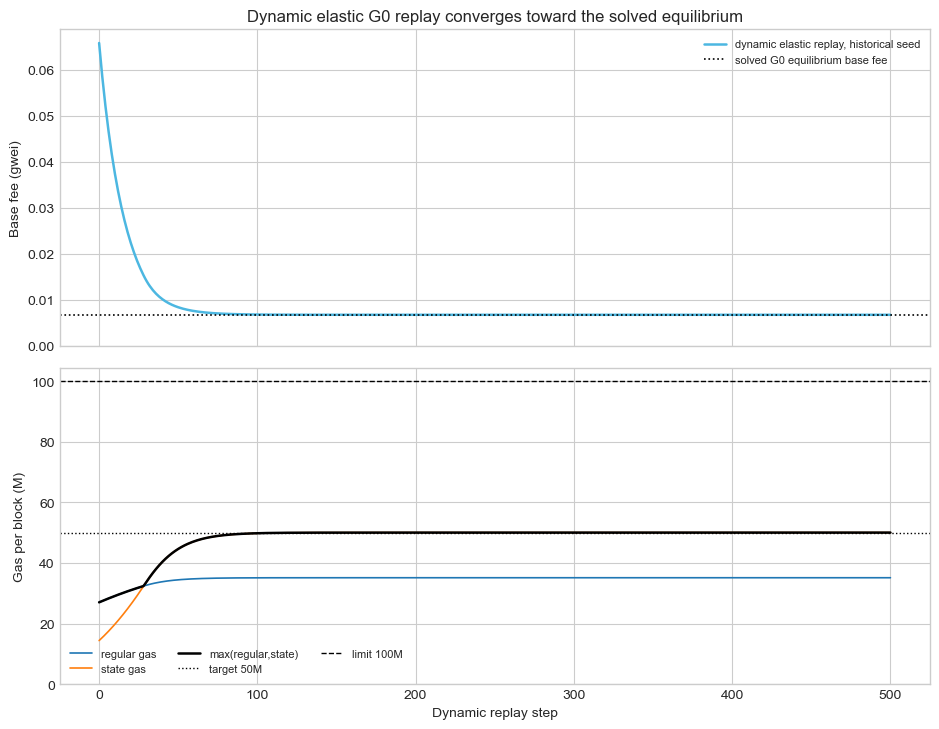

,case,steps,initial_base_fee_gwei,final_base_fee_gwei,equilibrium_base_fee_gwei,final_ratio_to_equilibrium,initial_basefee_input_gas_M,final_basefee_input_gas_M,target_gas_M,final_binding_group
0,dynamic_elastic_G0_100M_historical_seed,500,0.065766,0.006683,0.006683,1.000002,27.000202,49.999941,50.000000,state


In [9]:
CENTRAL_GAS_LIMIT = 100_000_000
CENTRAL_GAS_TARGET = CENTRAL_GAS_LIMIT // 2
central_g0 = results[
    (results["gas_limit"] == CENTRAL_GAS_LIMIT)
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].iloc[0]
historical_seed_base_fee = int(blocks["base_fee_per_gas"].iloc[0])
equilibrium_seed_base_fee = int(round(central_g0["base_fee_gwei"] * 1e9))

DYNAMIC_REPLAY_STEPS = len(blocks)


def dynamic_g0_usage_at_base_fee(base_fee_wei: float) -> dict:
    price_ratios = {
        name: multipliers[name] * float(base_fee_wei) / base_fee_ref
        for name in ["execution", "data", "state"]
    }
    quantities = demand_at_price_ratios(anchor_h0, central_params, price_ratios)
    regular_metered = (
        quantities["execution"] * multipliers["execution"]
        + quantities["data"] * multipliers["data"]
    )
    state_metered = quantities["state"] * multipliers["state"]
    basefee_input = max(regular_metered, state_metered)
    return {
        "execution_physical_gas": quantities["execution"],
        "data_physical_gas": quantities["data"],
        "state_physical_gas": quantities["state"],
        "regular_metered_gas": regular_metered,
        "state_metered_gas": state_metered,
        "basefee_input_gas": basefee_input,
        "binding_group": "state" if state_metered >= regular_metered else "regular",
        **{f"price_ratio_{name}": value for name, value in price_ratios.items()},
    }


dynamic_rows = []
base_fee = historical_seed_base_fee
for step in range(DYNAMIC_REPLAY_STEPS + 1):
    usage = dynamic_g0_usage_at_base_fee(base_fee)
    dynamic_rows.append({
        "step": step,
        "base_fee": base_fee,
        "base_fee_gwei": base_fee / 1e9,
        "equilibrium_base_fee": equilibrium_seed_base_fee,
        "equilibrium_base_fee_gwei": equilibrium_seed_base_fee / 1e9,
        "base_fee_ratio_to_equilibrium": base_fee / equilibrium_seed_base_fee,
        **usage,
    })
    if step == DYNAMIC_REPLAY_STEPS:
        break
    base_fee = update_eip1559_base_fee(
        parent_base_fee=base_fee,
        gas_used=int(min(usage["basefee_input_gas"], CENTRAL_GAS_LIMIT)),
        gas_target=CENTRAL_GAS_TARGET,
        min_base_fee=1,
    )

dynamic_replay = pd.DataFrame(dynamic_rows)
dynamic_replay.to_csv(OUT_DYNAMIC_REPLAY_CSV, index=False)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.4), sharex=True)

ax = axes[0]
ax.plot(
    dynamic_replay["step"],
    dynamic_replay["base_fee_gwei"],
    color="#4CB7E1",
    linewidth=1.8,
    label="dynamic elastic replay, historical seed",
)
ax.axhline(
    equilibrium_seed_base_fee / 1e9,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="solved G0 equilibrium base fee",
)
ax.set_ylabel("Base fee (gwei)")
ax.set_title("Dynamic elastic G0 replay converges toward the solved equilibrium")
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(
    dynamic_replay["step"],
    dynamic_replay["regular_metered_gas"] / 1e6,
    label="regular gas",
    linewidth=1.2,
)
ax.plot(
    dynamic_replay["step"],
    dynamic_replay["state_metered_gas"] / 1e6,
    label="state gas",
    linewidth=1.2,
)
ax.plot(
    dynamic_replay["step"],
    dynamic_replay["basefee_input_gas"] / 1e6,
    label="max(regular,state)",
    linewidth=1.8,
    color="black",
)
ax.axhline(CENTRAL_GAS_TARGET / 1e6, color="black", linestyle=":", linewidth=1, label="target 50M")
ax.axhline(CENTRAL_GAS_LIMIT / 1e6, color="black", linestyle="--", linewidth=1, label="limit 100M")
ax.set_ylabel("Gas per block (M)")
ax.set_xlabel("Dynamic replay step")
ax.set_ylim(bottom=0)
ax.legend(ncols=3, fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_dynamic_elastic_replay_check_{BLOCK_LABEL}.png", dpi=160)
plt.show()

dynamic_summary = pd.DataFrame([
    {
        "case": "dynamic_elastic_G0_100M_historical_seed",
        "steps": DYNAMIC_REPLAY_STEPS,
        "initial_base_fee_gwei": dynamic_replay["base_fee_gwei"].iloc[0],
        "final_base_fee_gwei": dynamic_replay["base_fee_gwei"].iloc[-1],
        "equilibrium_base_fee_gwei": equilibrium_seed_base_fee / 1e9,
        "final_ratio_to_equilibrium": dynamic_replay["base_fee_ratio_to_equilibrium"].iloc[-1],
        "initial_basefee_input_gas_M": dynamic_replay["basefee_input_gas"].iloc[0] / 1e6,
        "final_basefee_input_gas_M": dynamic_replay["basefee_input_gas"].iloc[-1] / 1e6,
        "target_gas_M": CENTRAL_GAS_TARGET / 1e6,
        "final_binding_group": dynamic_replay["binding_group"].iloc[-1],
    }
])
dynamic_summary


## 0.7-Style Elastic Replay Diagnostic

Notebook `0.7` is a passive block-by-block replay: demand is fixed, and each block updates the EIP-1559 base fee from the previous block's `max(regular, state)` gas.

The equilibrium solve above is different: it gives a counterfactual G0 reference level, not a block-by-block trajectory.

This section bridges the two with an **aggregate / average-multiplier elastic replay**. It takes each H0 block resource vector, applies the central elastic G0 equilibrium scale factor for each resource, and then applies the average G0/H0 metering multiplier:

$$
g^{\text{elastic},G0,aggregate}_{r,b}
=
q^{H0}_{r,b} \cdot s_r \cdot \bar m_r
$$

where:

$$
s_r
=
\frac{q^{\text{equilibrium},G0}_{r}}
       {\bar q^{H0}_{r}}
$$

and:

$$
\bar m_r
=
\frac{\sum_b g^{\text{passive},G0}_{r,b}}
       {\sum_b q^{H0}_{r,b}}
$$

This aggregate formulation is useful because it is directly tied to the mean-level G0 equilibrium solve. It preserves the mean resource repricing exactly, but it smooths away block-level heterogeneity from EIP-7976, EIP-7981, and EIP-8037. The next section introduces a block-specific replay scaling to preserve that heterogeneity.

The replay then runs the same EIP-1559 update loop as `0.7` with:

$$
\text{target}_{G0} = 50\text{M},
\qquad
\text{limit}_{G0} = 100\text{M}
$$

This is a diagnostic replay, not a fully endogenous dynamic demand model. It assumes the demand response is homogeneous within each resource, and over-limit demand is clipped rather than queued into later blocks.


In [10]:
CENTRAL_GAS_LIMIT = 100_000_000
CENTRAL_GAS_TARGET = CENTRAL_GAS_LIMIT // 2
central_g0 = results[
    (results["gas_limit"] == CENTRAL_GAS_LIMIT)
    & np.isclose(results["eta_data"], ETA_DATA_CENTRAL)
].iloc[0]

physical_scale = {
    "execution": central_g0["execution_physical_gas_M"] * 1e6 / blocks["h0_execution_gas"].mean(),
    "data": central_g0["data_physical_gas_M"] * 1e6 / blocks["h0_data_gas"].mean(),
    "state": central_g0["state_physical_gas_M"] * 1e6 / blocks["h0_state_gas"].mean(),
}

elastic_replay = blocks.copy()
elastic_replay["g0_passive_basefee_input_gas"] = elastic_replay["g0_max_regular_state_gas"]
elastic_replay["g0_passive_basefee_input_gas_for_base_fee"] = elastic_replay[
    "g0_passive_basefee_input_gas"
].clip(upper=CENTRAL_GAS_LIMIT)

# Main elastic replay: scale the already Glamsterdam-repriced block vectors.
elastic_replay["g0_elastic_execution_gas"] = (
    elastic_replay["g0_execution_gas"] * physical_scale["execution"]
)
elastic_replay["g0_elastic_data_gas"] = (
    elastic_replay["g0_data_gas"] * physical_scale["data"]
)
elastic_replay["g0_elastic_state_gas"] = (
    elastic_replay["g0_state_gas"] * physical_scale["state"]
)

# Legacy diagnostic only: average-multiplier approximation used in the earlier draft.
elastic_replay["legacy_avg_multiplier_execution_gas"] = (
    elastic_replay["h0_execution_gas"]
    * physical_scale["execution"]
    * multipliers["execution"]
)
elastic_replay["legacy_avg_multiplier_data_gas"] = (
    elastic_replay["h0_data_gas"]
    * physical_scale["data"]
    * multipliers["data"]
)
elastic_replay["legacy_avg_multiplier_state_gas"] = (
    elastic_replay["h0_state_gas"]
    * physical_scale["state"]
    * multipliers["state"]
)
elastic_replay["legacy_avg_multiplier_regular_gas"] = (
    elastic_replay["legacy_avg_multiplier_execution_gas"]
    + elastic_replay["legacy_avg_multiplier_data_gas"]
)
elastic_replay["legacy_avg_multiplier_basefee_input_gas"] = elastic_replay[[
    "legacy_avg_multiplier_regular_gas",
    "legacy_avg_multiplier_state_gas",
]].max(axis=1)
elastic_replay["g0_elastic_regular_gas"] = (
    elastic_replay["g0_elastic_execution_gas"]
    + elastic_replay["g0_elastic_data_gas"]
)
elastic_replay["g0_elastic_basefee_input_gas"] = elastic_replay[[
    "g0_elastic_regular_gas",
    "g0_elastic_state_gas",
]].max(axis=1)
elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"] = elastic_replay[
    "g0_elastic_basefee_input_gas"
].clip(upper=CENTRAL_GAS_LIMIT)
elastic_replay["g0_elastic_limit_exceeded"] = (
    elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT
)


def replay_eip1559_base_fee(gas_used_series: pd.Series, *, seed_base_fee: int) -> list[int]:
    base_fee = int(seed_base_fee)
    base_fees = []
    for gas_used in gas_used_series:
        base_fees.append(base_fee)
        base_fee = update_eip1559_base_fee(
            parent_base_fee=base_fee,
            gas_used=int(min(gas_used, CENTRAL_GAS_LIMIT)),
            gas_target=CENTRAL_GAS_TARGET,
            min_base_fee=1,
        )
    return base_fees

historical_seed_base_fee = int(elastic_replay["base_fee_per_gas"].iloc[0])
equilibrium_seed_base_fee = int(round(central_g0["base_fee_gwei"] * 1e9))

elastic_replay["g0_passive_100m_base_fee"] = replay_eip1559_base_fee(
    elastic_replay["g0_passive_basefee_input_gas_for_base_fee"],
    seed_base_fee=historical_seed_base_fee,
)
elastic_replay["g0_elastic_100m_base_fee"] = replay_eip1559_base_fee(
    elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"],
    seed_base_fee=historical_seed_base_fee,
)
elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"] = replay_eip1559_base_fee(
    elastic_replay["g0_elastic_basefee_input_gas_for_base_fee"],
    seed_base_fee=equilibrium_seed_base_fee,
)
elastic_replay["legacy_avg_multiplier_basefee_input_gas_for_base_fee"] = elastic_replay[
    "legacy_avg_multiplier_basefee_input_gas"
].clip(upper=CENTRAL_GAS_LIMIT)
elastic_replay["legacy_avg_multiplier_100m_base_fee"] = replay_eip1559_base_fee(
    elastic_replay["legacy_avg_multiplier_basefee_input_gas_for_base_fee"],
    seed_base_fee=historical_seed_base_fee,
)
elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"] = replay_eip1559_base_fee(
    elastic_replay["legacy_avg_multiplier_basefee_input_gas_for_base_fee"],
    seed_base_fee=equilibrium_seed_base_fee,
)
elastic_replay["g0_equilibrium_base_fee"] = equilibrium_seed_base_fee

elastic_replay.to_csv(OUT_ELASTIC_REPLAY_CSV, index=False)

replay_summary = pd.DataFrame([
    {
        "case": "passive_G0_100M",
        "mean_basefee_input_gas_M": elastic_replay["g0_passive_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_passive_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_passive_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_passive_100m_base_fee"].mean() / 1e9,
    },
    {
        "case": "legacy_avg_multiplier_G0_100M_seeded_historical",
        "mean_basefee_input_gas_M": elastic_replay["legacy_avg_multiplier_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee"].mean() / 1e9,
    },
    {
        "case": "legacy_avg_multiplier_G0_100M_seeded_equilibrium",
        "mean_basefee_input_gas_M": elastic_replay["legacy_avg_multiplier_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"].mean() / 1e9,
    },
    {
        "case": "elastic_G0_100M_seeded_historical",
        "mean_basefee_input_gas_M": elastic_replay["g0_elastic_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee"].mean() / 1e9,
    },
    {
        "case": "elastic_G0_100M_seeded_equilibrium",
        "mean_basefee_input_gas_M": elastic_replay["g0_elastic_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "initial_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].iloc[0] / 1e9,
        "final_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].iloc[-1] / 1e9,
        "mean_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].mean() / 1e9,
    },
])

pd.DataFrame([
    {"resource": name, "physical_scale_to_elastic_G0": value}
    for name, value in physical_scale.items()
]), replay_summary

(    resource  physical_scale_to_elastic_G0
 0  execution                      1.318132
 1       data                      1.029162
 2      state                      1.744251,
                                                case  mean_basefee_input_gas_M  \
 0                                   passive_G0_100M                 33.316308   
 1   legacy_avg_multiplier_G0_100M_seeded_historical                 52.287025   
 2  legacy_avg_multiplier_G0_100M_seeded_equilibrium                 52.287025   
 3                 elastic_G0_100M_seeded_historical                 52.661726   
 4                elastic_G0_100M_seeded_equilibrium                 52.661726   
 
    target_exceed_blocks  limit_exceed_blocks  initial_base_fee_gwei  \
 0                    72                    3               0.065766   
 1                   227                   28               0.065766   
 2                   227                   28               0.006683   
 3                   222                 

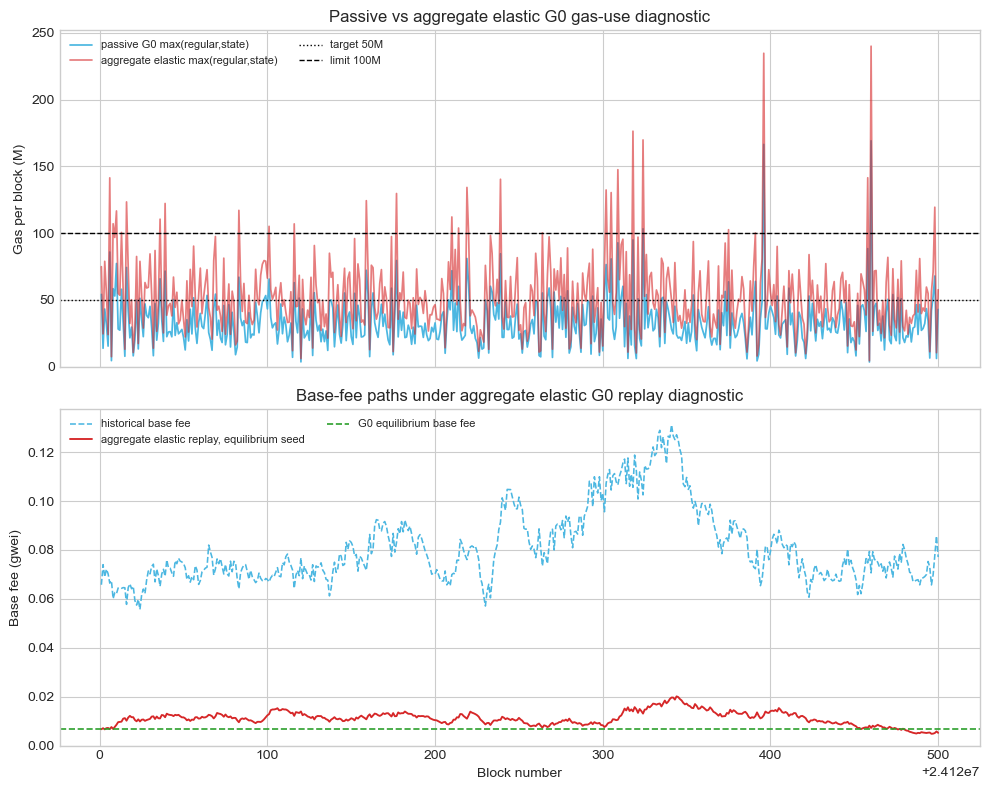

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_passive_basefee_input_gas"] / 1e6,
    label="passive G0 max(regular,state)",
    linewidth=1.25,
    color="#4CB7E1",
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["legacy_avg_multiplier_basefee_input_gas"] / 1e6,
    label="aggregate elastic max(regular,state)",
    linewidth=1.25,
    color="#d62728",
    alpha=0.6,
)
ax.axhline(CENTRAL_GAS_TARGET / 1e6, color="black", linestyle=":", linewidth=1, label="target 50M")
ax.axhline(CENTRAL_GAS_LIMIT / 1e6, color="black", linestyle="--", linewidth=1, label="limit 100M")
ax.set_ylabel("Gas per block (M)")
ax.set_ylim(bottom=0)
ax.set_title("Passive vs aggregate elastic G0 gas-use diagnostic")
ax.legend(ncols=2, fontsize=8)

ax = axes[1]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["base_fee_per_gas"] / 1e9,
    label="historical base fee",
    linewidth=1.15,
    linestyle="--",
    color="#4CB7E1",
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"] / 1e9,
    label="aggregate elastic replay, equilibrium seed",
    linewidth=1.35,
    color="#d62728",
)
ax.axhline(
    equilibrium_seed_base_fee / 1e9,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.2,
    label="G0 equilibrium base fee",
)
ax.set_ylabel("Base fee (gwei)")
ax.set_xlabel("Block number")
ax.set_ylim(bottom=0)
ax.set_title("Base-fee paths under aggregate elastic G0 replay diagnostic")
ax.legend(ncols=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_elastic_replay_diagnostic_{BLOCK_LABEL}.png", dpi=160)
plt.show()


## Replay Scaling Formulation Check

The aggregate replay above uses:

$$
g^{\text{elastic},G0,aggregate}_{r,b}
=
q^{H0}_{r,b} \cdot s_r \cdot \bar m_r
$$

That is correct at the mean level, but it smooths away the block-level variation in the Glamsterdam repricing rules. In particular, EIP-7976's calldata floor, EIP-7981's access-list cost, and EIP-8037's state gas do not bind uniformly across blocks.

To preserve the block-by-block shape, we introduce a second scaling formulation:

$$
g^{\text{elastic},G0,block}_{r,b}
=
s_r \cdot g^{\text{passive},G0}_{r,b}
$$

This starts from the already-repriced passive G0 block vector, then applies the same equilibrium demand scale $s_r$. It nests the passive G0 replay when $s_r = 1$ and keeps block-level repricing heterogeneity intact.

Both paths are stored in `g0_elastic_replay_diagnostic_24120001_24120500.csv`. The table and plot below compare the aggregate/average-multiplier replay against the block-specific replay.


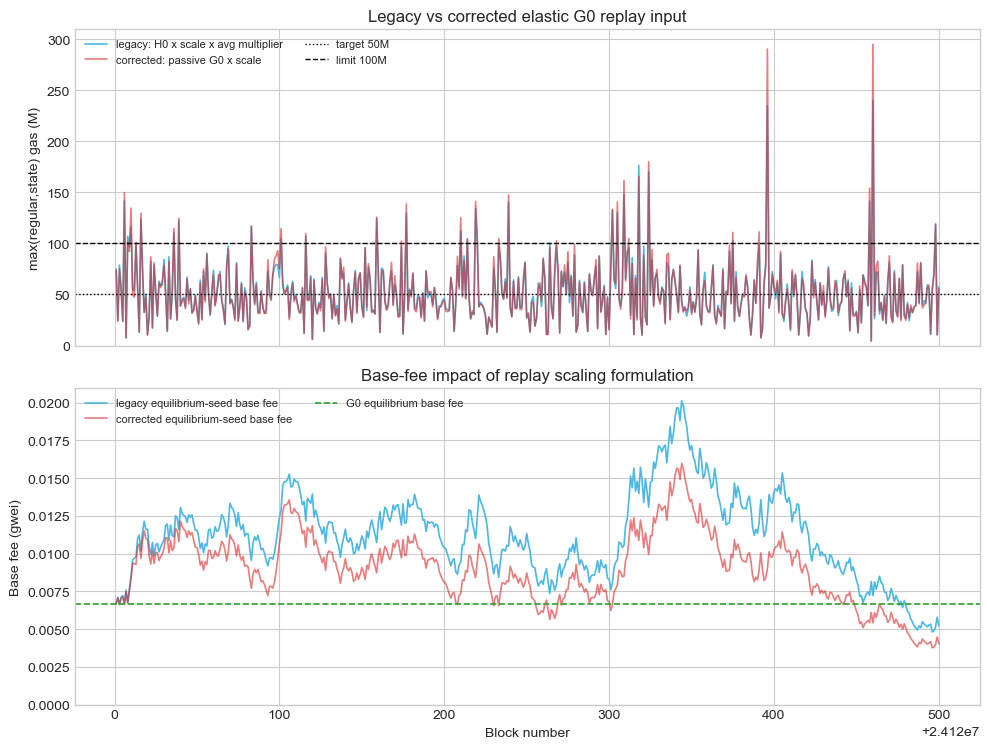

,formulation,mean_basefee_input_gas_M,target_exceed_blocks,limit_exceed_blocks,state_binding_share,mean_equilibrium_seed_base_fee_gwei,final_equilibrium_seed_base_fee_gwei,median_abs_pct_difference_vs_legacy,max_abs_pct_difference_vs_legacy
0,legacy_h0_times_average_multiplier,52.287025,227,28,0.760000,0.011226,0.005210,NaN,NaN
1,corrected_block_specific_g0_repriced_then_scaled,52.661726,222,32,0.722000,0.009049,0.004039,0.032723,0.236768


In [12]:
scaling_diff = (
    elastic_replay["g0_elastic_basefee_input_gas"]
    - elastic_replay["legacy_avg_multiplier_basefee_input_gas"]
)
scaling_diff_pct = scaling_diff / elastic_replay["legacy_avg_multiplier_basefee_input_gas"]

scaling_formulation_diagnostic = pd.DataFrame([
    {
        "formulation": "legacy_h0_times_average_multiplier",
        "mean_basefee_input_gas_M": elastic_replay["legacy_avg_multiplier_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["legacy_avg_multiplier_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "state_binding_share": float((elastic_replay["legacy_avg_multiplier_state_gas"] >= elastic_replay["legacy_avg_multiplier_regular_gas"]).mean()),
        "mean_equilibrium_seed_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"].mean() / 1e9,
        "final_equilibrium_seed_base_fee_gwei": elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"].iloc[-1] / 1e9,
        "median_abs_pct_difference_vs_legacy": np.nan,
        "max_abs_pct_difference_vs_legacy": np.nan,
    },
    {
        "formulation": "corrected_block_specific_g0_repriced_then_scaled",
        "mean_basefee_input_gas_M": elastic_replay["g0_elastic_basefee_input_gas"].mean() / 1e6,
        "target_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_TARGET).sum()),
        "limit_exceed_blocks": int((elastic_replay["g0_elastic_basefee_input_gas"] > CENTRAL_GAS_LIMIT).sum()),
        "state_binding_share": float((elastic_replay["g0_elastic_state_gas"] >= elastic_replay["g0_elastic_regular_gas"]).mean()),
        "mean_equilibrium_seed_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].mean() / 1e9,
        "final_equilibrium_seed_base_fee_gwei": elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"].iloc[-1] / 1e9,
        "median_abs_pct_difference_vs_legacy": scaling_diff_pct.abs().median(),
        "max_abs_pct_difference_vs_legacy": scaling_diff_pct.abs().max(),
    },
])

fig, axes = plt.subplots(2, 1, figsize=(10, 7.6), sharex=True)

ax = axes[0]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["legacy_avg_multiplier_basefee_input_gas"] / 1e6,
    label="legacy: H0 x scale x avg multiplier",
    linewidth=1.2,
    color="#4CB7E1",
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_elastic_basefee_input_gas"] / 1e6,
    label="corrected: passive G0 x scale",
    linewidth=1.2,
    color="#d62728",
    alpha=0.6,
)
ax.axhline(CENTRAL_GAS_TARGET / 1e6, color="black", linestyle=":", linewidth=1, label="target 50M")
ax.axhline(CENTRAL_GAS_LIMIT / 1e6, color="black", linestyle="--", linewidth=1, label="limit 100M")
ax.set_ylabel("max(regular,state) gas (M)")
ax.set_ylim(bottom=0)
ax.set_title("Legacy vs corrected elastic G0 replay input")
ax.legend(ncols=2, fontsize=8)

ax = axes[1]
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["legacy_avg_multiplier_100m_base_fee_seeded_at_equilibrium"] / 1e9,
    label="legacy equilibrium-seed base fee",
    linewidth=1.2,
    color="#4CB7E1",
)
ax.plot(
    elastic_replay["block_number"],
    elastic_replay["g0_elastic_100m_base_fee_seeded_at_equilibrium"] / 1e9,
    label="corrected equilibrium-seed base fee",
    linewidth=1.2,
    color="#d62728",
    alpha=0.6,
)
ax.axhline(equilibrium_seed_base_fee / 1e9, color="#2ca02c", linestyle="--", linewidth=1.2, label="G0 equilibrium base fee")
ax.set_ylabel("Base fee (gwei)")
ax.set_xlabel("Block number")
ax.set_ylim(bottom=0)
ax.set_title("Base-fee impact of replay scaling formulation")
ax.legend(ncols=2, fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_replay_scaling_formulation_comparison_{BLOCK_LABEL}.png", dpi=160)
plt.show()

scaling_formulation_diagnostic


## Data-Elasticity Prior Sweep

This sweep now varies the fixed $\epsilon_{\text{data}}^{\text{prior}}$ values from the EIP-7623 notebook. For each prior, we convert to the nested model's $\eta_{\text{data}}$ at the H0 pilot anchor:

$$
\eta_{\text{data}}^{\text{model}}
=
\frac{
  \epsilon_{\text{data}}^{\text{prior}}
  - \epsilon_{\text{rest}}^{H0}
}{
  1 - \alpha_{\text{data}|\text{rest}}^{H0}
}
$$

The central row therefore keeps the EIP-7623 recovered data elasticity fixed at about 0.487 instead of recomputing it from the 500-block pilot composition.


In [13]:
sweep = results[
    (results["gas_limit"] == 100_000_000)
    & (results["share_mode"] == "maria_own_price")
].copy()
sweep.to_csv(OUT_SWEEP_CSV, index=False)

sweep[[
    "epsilon_data_prior",
    "eta_data_model_H0_pilot",
    "alpha_data_given_rest_G0_physical",
    "epsilon_rest_G0",
    "epsilon_execution",
    "data_physical_gas_M",
    "execution_physical_gas_M",
    "valid_nonnegative_execution",
    "prior_interpretation",
]]


,epsilon_data_prior,eta_data_model_H0_pilot,alpha_data_given_rest_G0_physical,epsilon_rest_G0,epsilon_execution,data_physical_gas_M,execution_physical_gas_M,valid_nonnegative_execution,prior_interpretation
0,0.080000,0.000000,0.041984,0.086770,0.087067,1.400105,31.948510,True,fixed data/execution split
1,0.174751,0.072445,0.040210,0.086770,0.083084,1.340953,32.007662,True,sensitivity
2,0.364252,0.270251,0.035726,0.086770,0.076490,1.191396,32.157219,True,sensitivity
3,0.648504,0.566960,0.029890,0.086770,0.069463,0.996790,32.351825,True,sensitivity
4,1.027506,0.962571,0.023529,0.086770,0.064102,0.784654,32.563961,True,aggressive short-run sensitivity
5,0.389110,0.296198,0.035174,0.086770,0.075748,1.173010,32.175605,True,main long-window effective eta
6,0.486876,0.398248,0.033084,0.086770,0.073080,1.103319,32.245296,True,state-cleaned long-window effective eta


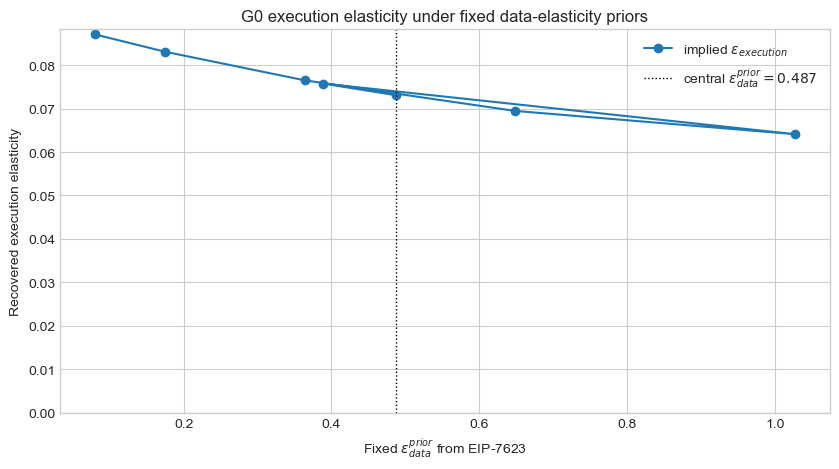

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(
    sweep["epsilon_data_prior"],
    sweep["epsilon_execution"],
    marker="o",
    label=r"implied $\epsilon_{execution}$",
)
ax.axvline(
    EPSILON_DATA_CENTRAL,
    color="black",
    linestyle=":",
    linewidth=1,
    label=rf"central $\epsilon_{{data}}^{{prior}}={EPSILON_DATA_CENTRAL:.3f}$",
)
ax.set_xlabel(r"Fixed $\epsilon_{data}^{prior}$ from EIP-7623")
ax.set_ylabel("Recovered execution elasticity")
ax.set_title("G0 execution elasticity under fixed data-elasticity priors")
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_eta_data_elasticity_sweep_{BLOCK_LABEL}.png", dpi=160)
plt.show()


## Passive vs Elastic G0 Resource Use

This plot compares:

- observed H0 gas decomposition;
- passive G0 repricing of the same 500 blocks;
- central elastic G0 equilibrium at the 100M limit.

Again, BAL is excluded from G0 gas. BAL will enter as priced bandwidth only in Mechanism A/B.

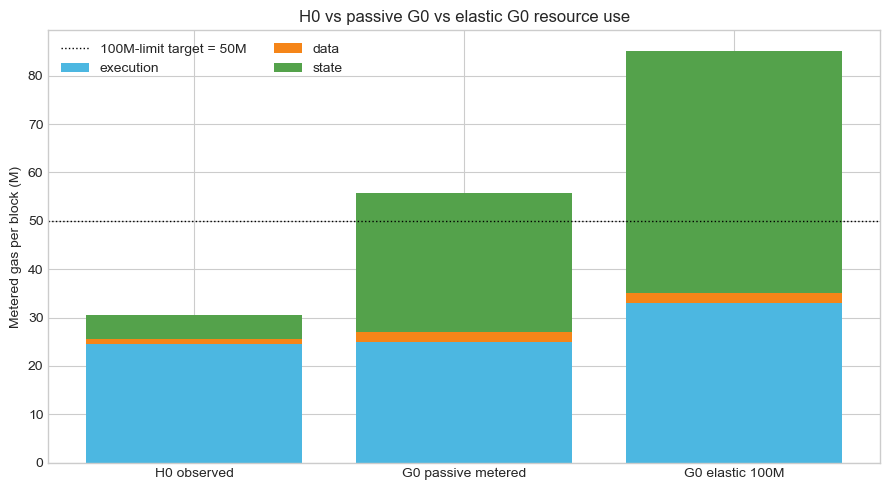

,execution,data,state
case,,,
H0 observed,24.462873,1.072056,4.935713
G0 passive metered,25.042216,2.042926,28.665593
G0 elastic 100M,33.008946,2.102502,50.000000


In [15]:
central_maria = central[central["share_mode"] == "maria_own_price"].iloc[0]
plot_rows = [
    {
        "case": "H0 observed",
        "execution": blocks["h0_execution_gas"].mean() / 1e6,
        "data": blocks["h0_data_gas"].mean() / 1e6,
        "state": blocks["h0_state_gas"].mean() / 1e6,
    },
    {
        "case": "G0 passive metered",
        "execution": blocks["g0_execution_gas"].mean() / 1e6,
        "data": blocks["g0_data_gas"].mean() / 1e6,
        "state": blocks["g0_state_gas"].mean() / 1e6,
    },
    {
        "case": "G0 elastic 100M",
        "execution": central_maria["execution_metered_gas_M"],
        "data": central_maria["data_metered_gas_M"],
        "state": central_maria["state_metered_gas_M"],
    },
]
plot_df = pd.DataFrame(plot_rows).set_index("case")

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(plot_df))
colors = {"execution": "#4CB7E1", "data": "#F58518", "state": "#54A24B"}
for col in ["execution", "data", "state"]:
    ax.bar(plot_df.index, plot_df[col], bottom=bottom, label=col, color=colors[col])
    bottom += plot_df[col].values
ax.axhline(50, color="black", linestyle=":", linewidth=1, label="100M-limit target = 50M")
ax.set_ylabel("Metered gas per block (M)")
ax.set_title("H0 vs passive G0 vs elastic G0 resource use")
ax.legend(ncols=2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"g0_resource_use_{BLOCK_LABEL}.png", dpi=160)
plt.show()

plot_df

## Outputs

This notebook writes:

- `data/g0_reference_decomposition_24120001_24120500.csv`
- `data/g0_elastic_reference_results_24120001_24120500.csv`
- `data/g0_equilibrium_base_fee_model_24120001_24120500.csv`
- `data/g0_eta_data_sweep_24120001_24120500.csv`
- `data/g0_elastic_replay_diagnostic_24120001_24120500.csv`
- `data/g0_dynamic_elastic_replay_check_24120001_24120500.csv`
- `plots/g0_equilibrium_base_fee_model_24120001_24120500.png`
- `plots/g0_eta_data_elasticity_sweep_24120001_24120500.png`
- `plots/g0_elastic_replay_diagnostic_24120001_24120500.png`
- `plots/g0_replay_scaling_formulation_comparison_24120001_24120500.png`
- `plots/g0_dynamic_elastic_replay_check_24120001_24120500.png`
- `plots/g0_resource_use_24120001_24120500.png`

The main row to carry forward into Mechanism A/B is the 100M-limit central `epsilon_data_prior` row from the state-cleaned EIP-7623 event study. The `eta_data` column is the H0-pilot model conversion used by the nested demand system.


### BAL Diagnostic

BAL bytes are present in the historical payload, but they are not priced in G0.
The table below records their size only as a diagnostic. G0 gas remains execution + data folded into regular gas + EIP-8037 state gas.

In [16]:
bal_diagnostic = pd.DataFrame([{
    "mean_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].mean(),
    "p95_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].quantile(0.95),
    "max_bal_rlp_bytes_per_block": blocks["bal_rlp_bytes"].max(),
    "g0_bal_gas": 0,
    "note": "BAL is payload diagnostic only in G0; it is priced in Mechanism A/B bandwidth.",
}])
bal_diagnostic

,mean_bal_rlp_bytes_per_block,p95_bal_rlp_bytes_per_block,max_bal_rlp_bytes_per_block,g0_bal_gas,note
0,"148,168.182000","295,901.050000",363031,0,BAL is payload diagnostic only in G0; it is pr...
